### CDOM processing

Example of usage of the ProLab module to the processing of CDOM absorption measurements.

#### Loading libraries

First of all, we need to load the required libraries:

In [1]:
import prolab as pl
import pandas as pd

#### Loading data

In this example, we are going to process data from an estuary. The samples have variable salinity and were measured using the WPI UltraPath setup, i.e., a salinity correction is required.

Let's upload the salinity curves (already processed) that are going to be used as blank curves:

In [2]:
salinity_curves = pd.read_csv('data/sal_curve_interpolated_202604.csv',
                              sep=';',
                              index_col=0)
salinity_curves.head(5)

,310,311,312,313,314,315,316,317,318,319,...,711,712,713,714,715,716,717,718,719,720
salinity,,,,,,,,,,,,,,,,,,,,,
0.0,0.000176,0.000166,0.000149,0.000111,0.000046,-0.000008,-0.000027,-0.000046,-0.000064,-0.000082,...,-0.002556,-0.002602,-0.002677,-0.002704,-0.002693,-0.002651,-0.002579,-0.002545,-0.002558,-0.002591
0.1,0.000230,0.000218,0.000200,0.000160,0.000093,0.000037,0.000016,-0.000004,-0.000024,-0.000044,...,-0.002526,-0.002572,-0.002646,-0.002672,-0.002662,-0.002620,-0.002547,-0.002514,-0.002526,-0.002558
0.2,0.000285,0.000271,0.000250,0.000209,0.000140,0.000082,0.000059,0.000038,0.000016,-0.000005,...,-0.002497,-0.002541,-0.002614,-0.002640,-0.002630,-0.002588,-0.002516,-0.002483,-0.002494,-0.002526
0.3,0.000339,0.000323,0.000301,0.000258,0.000186,0.000127,0.000103,0.000079,0.000056,0.000034,...,-0.002467,-0.002511,-0.002582,-0.002608,-0.002598,-0.002556,-0.002485,-0.002451,-0.002462,-0.002494
0.4,0.000393,0.000375,0.000351,0.000307,0.000233,0.000171,0.000146,0.000121,0.000097,0.000072,...,-0.002438,-0.002480,-0.002551,-0.002576,-0.002566,-0.002525,-0.002454,-0.002420,-0.002430,-0.002461


Notice that each row represents a different salinity, while the columns are the wavelengths. When passing blank curves to the correction, this is the expected format. If a single curve is passed as blank, it must also be in this format.

Now, we can upload the measured spectra:

In [3]:
raw_data = pl.read_files(path='data/cdom_ex',
                         instrument='wpi',
                         format_string='{pattern}{id:d}{rep}_{campaign}',
                         sample_pattern='ponto',
                         blank_pattern=None,
                         trans_pattern=None,
                         depig_pattern=None,
                         decimal='.')

**Tip**: whenever you need to check the function's documentation, try running `pl.read_files?`.

**Note**: the `format_string` argument is crucial to the proper functioning of the whole processing, therefore the naming convention must follow standards that make the life easier. The naming convention of this example is not the best. For CDOM files, we recommend a format string like `{site}_{pattern}_{id}_{rep}`, which would require files with names like `ssc_sample_p01_a.txt`, `ssc_blank_001_a.txt`...

Notice that the function above printed a warning saying that there are NaNs in the data. You may check the table to see what's going on, but in this case we already know that one of the readings had a problem and produced NaNs in the shorter wavelengths. In this case, we will simply remove the problematic row(s):

In [4]:
raw_data = raw_data.dropna(axis=0)
raw_data.tail(5)

,pattern,id,rep,campaign,is_blank,is_sample,310,311,312,313,...,711,712,713,714,715,716,717,718,719,720
key,,,,,,,,,,,,,,,,,,,,,
ponto05b_c01,ponto,5,b,c01,False,True,2.006897,1.990448,1.973862,1.956830,...,0.019401,0.019363,0.019349,0.019368,0.019411,0.019436,0.019442,0.019473,0.019531,0.019613
ponto05c_c01,ponto,5,c,c01,False,True,2.009500,1.992697,1.975834,1.958781,...,0.019273,0.019236,0.019221,0.019237,0.019274,0.019307,0.019334,0.019383,0.019457,0.019536
ponto06a_c01,ponto,6,a,c01,False,True,1.917947,1.900466,1.882711,1.864468,...,0.017444,0.017428,0.017450,0.017486,0.017533,0.017546,0.017527,0.017558,0.017649,0.017742
ponto06b_c01,ponto,6,b,c01,False,True,1.930514,1.913600,1.896086,1.878309,...,0.016605,0.016585,0.016586,0.016615,0.016665,0.016674,0.016645,0.016675,0.016774,0.016875
ponto06c_c01,ponto,6,c,c01,False,True,1.938146,1.921424,1.904473,1.886524,...,0.016687,0.016671,0.016664,0.016685,0.016727,0.016729,0.016696,0.016717,0.016801,0.016885


Above you can see if the format string separated the attributes properly. See that the format string is used as a key to retrieve important attributes from the file names, and these attributes are divided in columns.

#### Check consistency

Now that we have the salinity curves and the data properly configured, we can create our object of interest, called `Spectra`:

In [5]:
spectra = pl.Spectra(raw_data)
print(spectra)

Object Spectra with 24 observations and 411 wavelengths


As we have three measurements of each sampling station, we must check the consistency of these measurements. We can use the method (check the documentation for details):

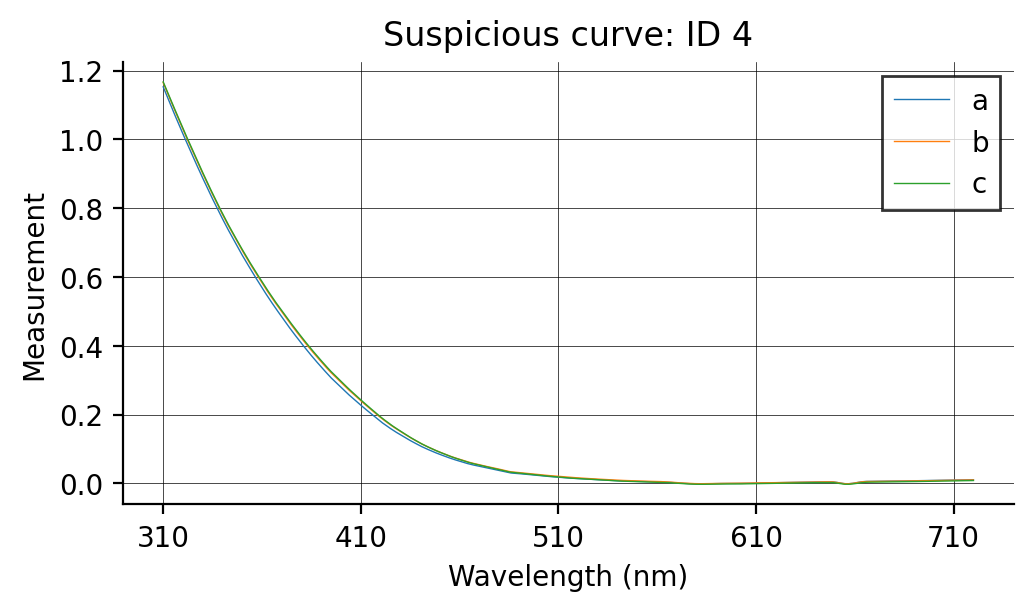

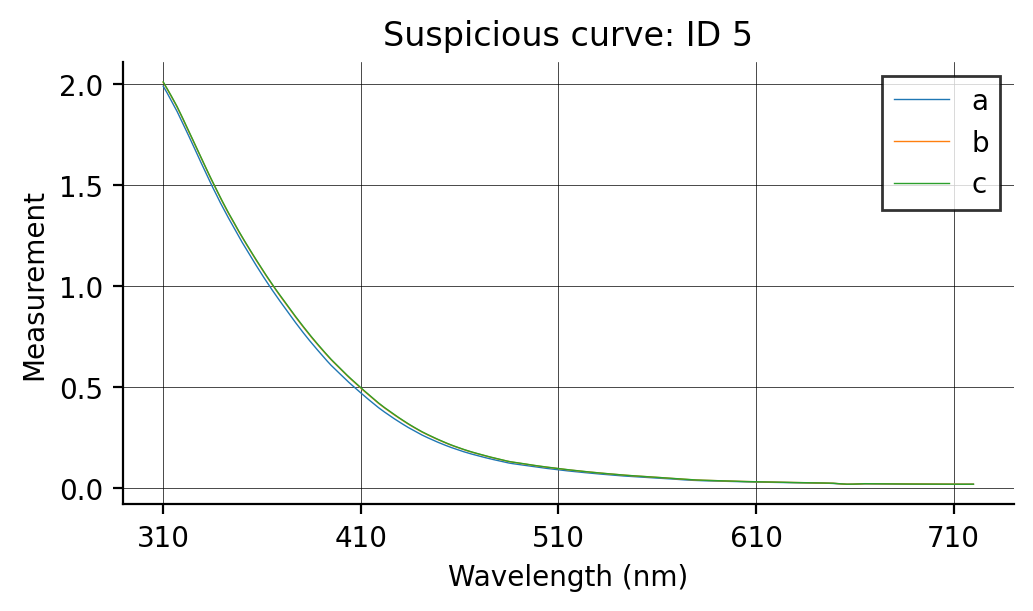

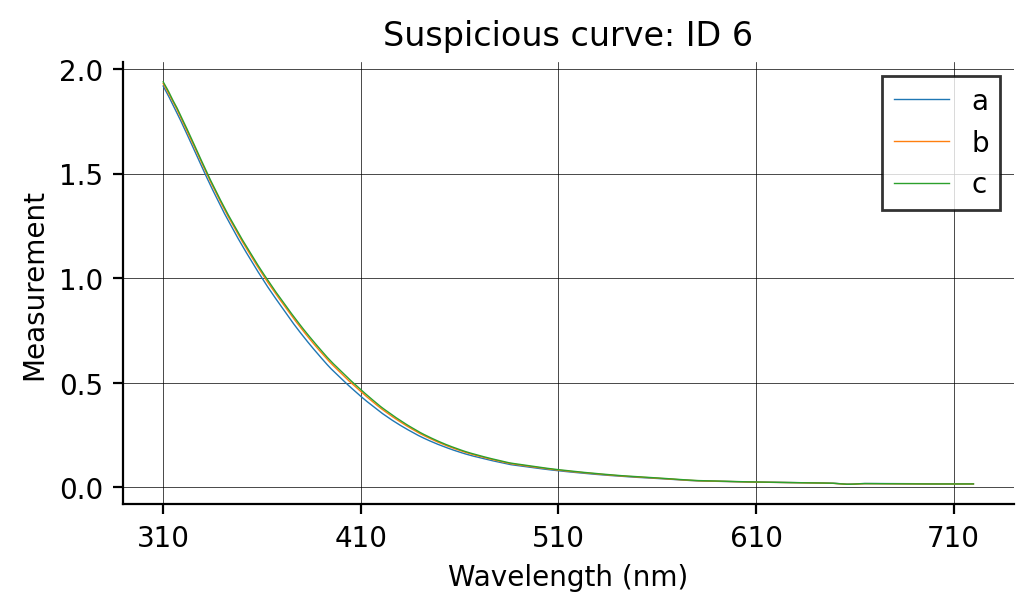

--------------------------
Suspicious curves removed:
ponto04a_c01
ponto05a_c01
ponto06a_c01
--------------------------
--------------------
No suspicious curves
--------------------


Spectra(observations=21, wavelengths=411)

In [6]:
spectra.consistency(std_threshold=0.01,
                    measurements='sample',
                    groupby='id',
                    remove_suspicious=True,
                    plot_suspicious=True,
                    recursive=True)

The plots above show the curves in which the standard deviation is higher than the threshold. After the plots, the IDs of the removed curves is also shown. Check to see whether they make sense.

#### Retrieve absorption

After removing suspect measurements we can finally retrieve absorption:

In [8]:
spectra.get_absorption(use_blank=True,
                       blank=salinity_curves,
                       wl_null_point_correction=600,
                       pathlength=0.1071)

The correction will use the salinity curves provided


Spectra(observations=24, wavelengths=411)

The warning is related to the null point correction. Check the function documentation for details about this warning.

Now, the curves are already corrected and converted to absorption. It's time to fit an exponential curve to them:

In [9]:
spectra.expfit(wl_ref=443,
               wl_range=(350, 500))
spectra.fitted

,a443,slope
id,,
1,0.340914,0.019497
2,0.623117,0.018179
3,0.872199,0.017248
4,3.286135,0.016522
5,6.117977,0.015865
6,5.742912,0.016038


Above we have the CDOM absorption at 443 nm, $a_{CDOM}(443)$, and the slope $S$ of the curve, which are parameters of the function

$$a_{CDOM}(\lambda) = a_{CDOM}(443) e^{S(\lambda-443)}$$

We can save the fitted parameters:

In [11]:
spectra.fitted.to_csv('data/fitted_cdom.csv', sep=';')

And also plot the curves:

<Axes: >

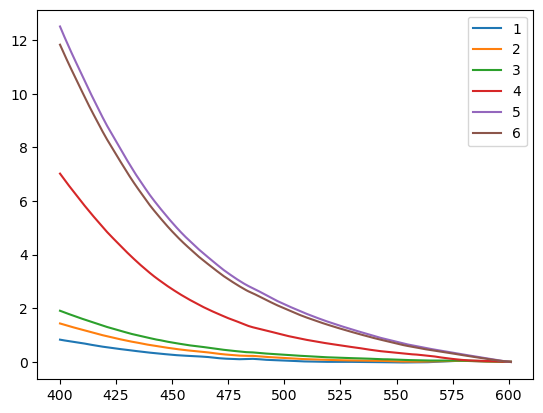

In [16]:
spectra.absorption.loc[:, 400:601].transpose().plot()